In [52]:
import pandas as pd

# Apresentando o dataset
df = pd.read_csv('car_price_dataset.csv')
display(df)

# Inicializar a lista global de resultados dos modelos
resultados_gerais = []


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


In [53]:
# Verificando o tipo de dado de cada atributo
df.dtypes

Brand            object
Model            object
Year              int64
Engine_Size     float64
Fuel_Type        object
Transmission     object
Mileage           int64
Doors             int64
Owner_Count       int64
Price             int64
dtype: object

In [54]:
# Apresentando se contém dados nulos e a quantidade por coluna
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [55]:
# Verificando se os nulos são linhas inteiras vazias ou dados dispersos
linhas_completamente_vazias = df.isnull().all(axis=1).sum()
linhas_com_algum_nulo = df.isnull().any(axis=1).sum()

print(f"Linhas com TODOS os valores nulos (completamente vazias): {linhas_completamente_vazias}")
print(f"Linhas com pelo menos UM valor nulo: {linhas_com_algum_nulo}")

if linhas_completamente_vazias == linhas_com_algum_nulo:
    print("\nCONCLUSÃO: Todos os nulos estão concentrados em linhas inteiras que estão totalmente em branco!")
else:
    print("\nCONCLUSÃO: Existem valores nulos dispersos pelo dataset (alguns dados preenchidos e outros faltando na mesma linha).")

Linhas com TODOS os valores nulos (completamente vazias): 0
Linhas com pelo menos UM valor nulo: 0

CONCLUSÃO: Todos os nulos estão concentrados em linhas inteiras que estão totalmente em branco!


In [56]:
# Removendo as linhas com valores nulos do dataset
df_limpo = df.dropna()

print(f"Número de linhas ANTES da limpeza: {df.shape[0]}")
print(f"Número de linhas DEPOIS da limpeza: {df_limpo.shape[0]}")
print(f"Total de linhas nulas apagadas: {df.shape[0] - df_limpo.shape[0]}\n")

# Verificação final para garantir que não sobrou nenhum nulo
print("Quantidade de nulos após a limpeza:")
print(df_limpo.isnull().sum())

Número de linhas ANTES da limpeza: 10000
Número de linhas DEPOIS da limpeza: 10000
Total de linhas nulas apagadas: 0

Quantidade de nulos após a limpeza:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


In [57]:
# Analisando se os dados numéricos estão normalizados
print("Análise das escalas numéricas ANTES da Normalização:")
colunas_numericas = df_limpo.select_dtypes(include=['int64', 'float64']).columns
colunas_para_normalizar = [col for col in colunas_numericas if col not in ['Price']]

display(df_limpo[colunas_para_normalizar].describe().loc[['min', 'max']])

print("\nCONCLUSÃO: Os dados numéricos NÃO estão normalizados.")

Análise das escalas numéricas ANTES da Normalização:


,Year,Engine_Size,Mileage,Doors,Owner_Count
min,2000.0,1.0,25.0,2.0,1.0
max,2023.0,5.0,299947.0,5.0,5.0



CONCLUSÃO: Os dados numéricos NÃO estão normalizados.


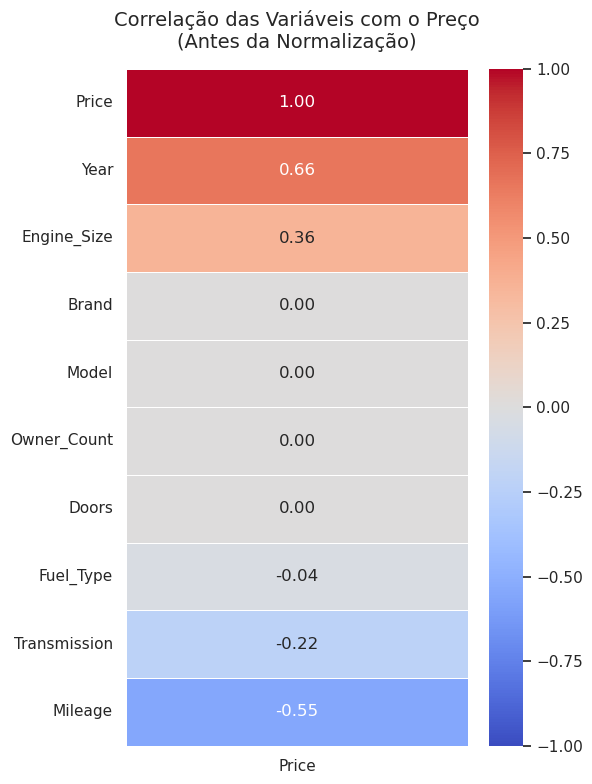

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapa de calor de correlação das variáveis APENAS com o Preço (Antes de Normalizar)
sns.set_theme(style="white")

df_corr = df_limpo.copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

correlacoes_preco = df_corr.corr()[['Price']].sort_values(by='Price', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(correlacoes_preco, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white')
plt.title('Correlação das Variáveis com o Preço\n(Antes da Normalização)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [59]:
# Normalizando as colunas numéricas MANUALMENTE (sem o uso do scikit-learn)
df_normalizado = df_limpo.copy()

for col in colunas_para_normalizar:
    valor_minimo = df_normalizado[col].min()
    valor_maximo = df_normalizado[col].max()
    df_normalizado[col] = (df_normalizado[col] - valor_minimo) / (valor_maximo - valor_minimo)

print("✅ Dados numéricos normalizados com sucesso (O Preço NÃO foi normalizado)!\n")
colunas_verificacao = colunas_para_normalizar + ['Price']
display(df_normalizado[colunas_verificacao].describe().loc[['min', 'max']])

✅ Dados numéricos normalizados com sucesso (O Preço NÃO foi normalizado)!



,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
min,0.0,0.0,0.0,0.0,0.0,2000.0
max,1.0,1.0,1.0,1.0,1.0,18301.0


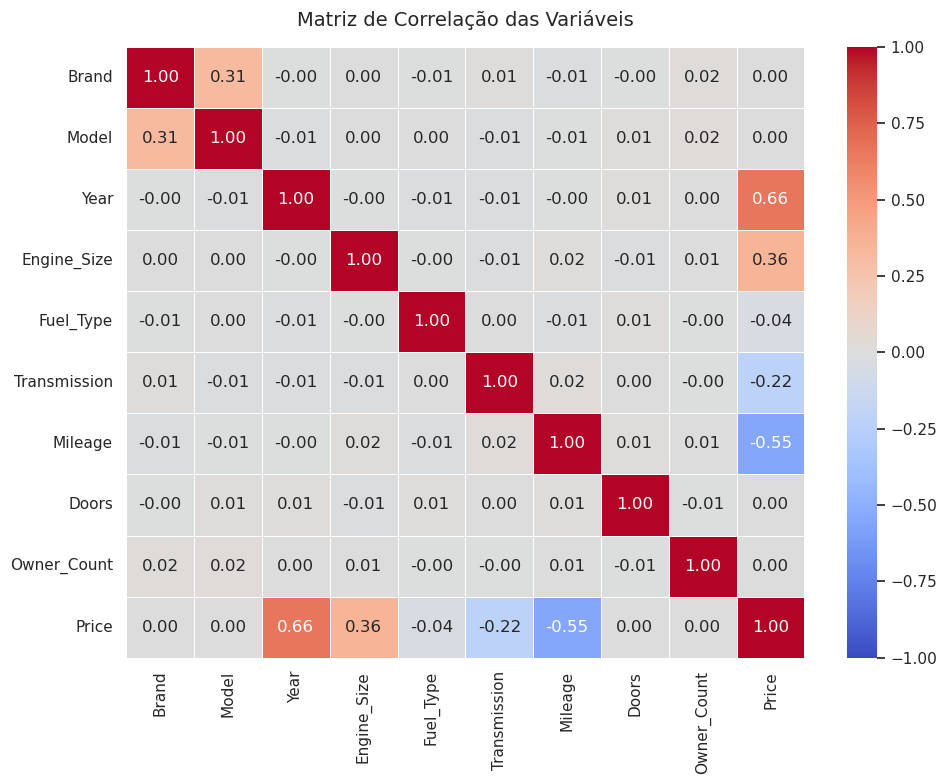

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# MATRIZ DE CORRELAÇÃO DE TODAS AS VARIÁVEIS (Gráfico Quadrado)
sns.set_theme(style="white")

df_matriz = df_limpo.copy()
for col in df_matriz.select_dtypes(include=['object']).columns:
    df_matriz[col] = df_matriz[col].astype('category').cat.codes

matriz_correlacao = df_matriz.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white')
plt.title('Matriz de Correlação das Variáveis', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

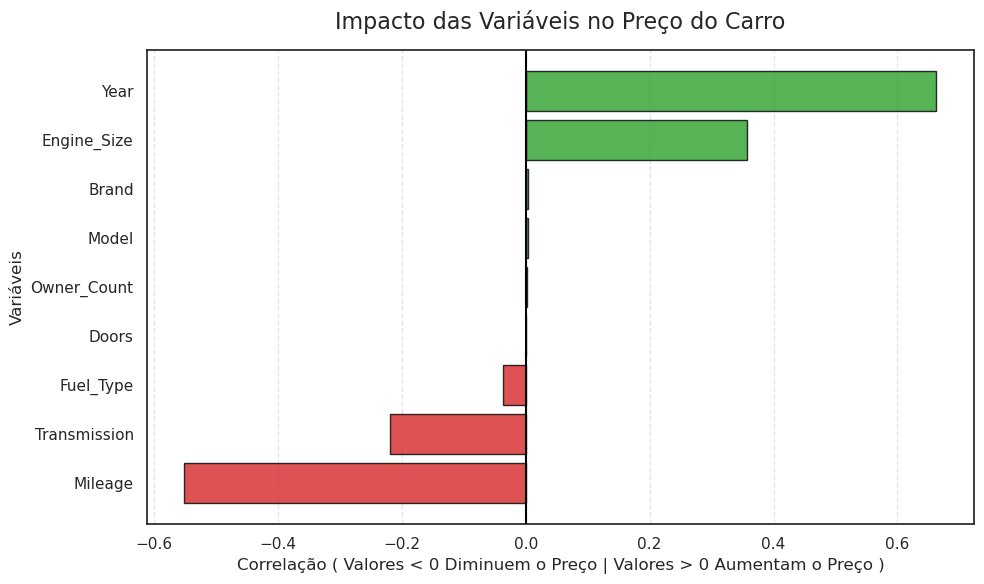

In [61]:
# Gráfico de barras horizontais mostrando o impacto (correlação) de cada variável no Preço
# Variáveis que diminuem o preço ficam à esquerda (vermelho)
# Variáveis que aumentam o preço ficam à direita (verde)

import matplotlib.pyplot as plt

if 'Price' in correlacoes_preco.index:
    corr_plot = correlacoes_preco.drop('Price')
else:
    corr_plot = correlacoes_preco.copy()

corr_plot = corr_plot.sort_values(by='Price')

plt.figure(figsize=(10, 6))
cores = ['#d62728' if x < 0 else '#2ca02c' for x in corr_plot['Price']]

plt.barh(corr_plot.index, corr_plot['Price'], color=cores, edgecolor='black', alpha=0.8)
plt.title('Impacto das Variáveis no Preço do Carro', fontsize=16, pad=15)
plt.xlabel('Correlação ( Valores < 0 Diminuem o Preço | Valores > 0 Aumentam o Preço )', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [62]:
# Removendo as 3 variáveis com correlação irrelevante (praticamente 0)
df_limpo = df_limpo.drop(columns=['Doors', 'Owner_Count', 'Model'])

# Atualizando a variável de correlações para o gráfico não dar erro
correlacoes_preco = correlacoes_preco.drop(index=['Doors', 'Owner_Count', 'Model'], errors='ignore')

print("Variáveis 'Doors', 'Owner_Count' e 'Model' foram removidas com sucesso!")


Variáveis 'Doors', 'Owner_Count' e 'Model' foram removidas com sucesso!


In [63]:
# Apresentando o dataset atualizado (agora sem as colunas Doors, Owner_Count e Model)
print("Formato do dataset após a remoção:", df_limpo.shape)
display(df_limpo.head())


Formato do dataset após a remoção: (10000, 7)


,Brand,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Price
0,Kia,2020,4.2,Diesel,Manual,289944,8501
1,Chevrolet,2012,2.0,Hybrid,Automatic,5356,12092
2,Mercedes,2020,4.2,Diesel,Automatic,231440,11171
3,Audi,2023,2.0,Electric,Manual,160971,11780
4,Volkswagen,2003,2.6,Hybrid,Semi-Automatic,286618,2867


Treinamento concluído em 2 épocas!
EQM Final no Treino: 0.095703



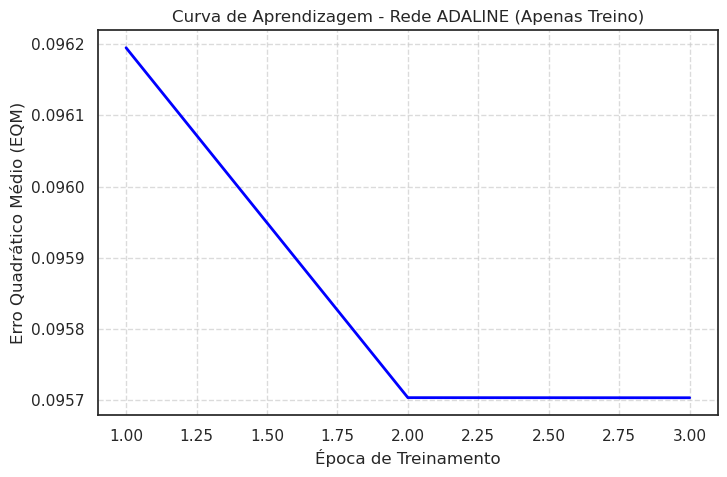

EQM no conjunto de Teste (Normalizado): 0.102827

--- Primeiras 10 predições no conjunto de TESTE (Linhas 800 a 810) ---


,Preço Real,Preço Predito (Adaline),Diferença
0,6012,5606.43,405.57
1,4008,5107.22,-1099.22
2,9379,10368.67,-989.67
3,9617,10280.23,-663.23
4,6843,7892.32,-1049.32
5,7438,7972.48,-534.48
6,13901,14221.63,-320.63
7,3441,4590.07,-1149.07
8,6354,4387.01,1966.99
9,11567,10927.08,639.92


In [64]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO REDE NEURAL ADALINE (REGRA DELTA)
# Parâmetros:
# - x0 = -1 (bias)
# - Inicialização de pesos aleatória (0 a 1)
# - Taxa de aprendizado = 0.005
# - Precisão = 10^-6
# - Conjunto: 800 treino / 200 teste
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# 1. Preparação dos dados
df = pd.read_csv('car_price_dataset.csv')
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

features = ['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']
X = df[features].values[:1000]
y = df['Price'].values[:1000].reshape(-1, 1)

# Normalização Z-Score
medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8
X_norm = (X - medias) / desvios

media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

# Inserindo o termo de bias x0 = -1 na matriz de entrada X
X_bias = np.c_[np.full(X_norm.shape[0], -1), X_norm]

# Divisão de Treino (800) e Teste (200)
X_treino = X_bias[:800]
y_treino = y_norm[:800]
X_teste = X_bias[800:1000]
y_teste = y_norm[800:1000]
y_teste_reais = y[800:1000]

# Parâmetros
taxa_aprendizado = 0.005
precisao = 1e-6
max_epocas = 1500

start_time = time.time()
np.random.seed(42)
w = np.random.rand(X_treino.shape[1])

erros_epocas = []
epoca = 0
eqm_anterior = float('inf')

while epoca < max_epocas:
    for i in range(len(X_treino)):
        u = np.dot(w, X_treino[i])
        erro = y_treino[i][0] - u
        w = w + taxa_aprendizado * erro * X_treino[i]
    
    u_todos = np.dot(X_treino, w)
    erros_amostras = y_treino.flatten() - u_todos
    eqm_atual = np.mean(erros_amostras**2)
    erros_epocas.append(eqm_atual)
    
    if abs(eqm_anterior - eqm_atual) < precisao:
        break
    eqm_anterior = eqm_atual
    epoca += 1

tempo_treino = time.time() - start_time

print(f"Treinamento concluído em {epoca} épocas!")
print(f"EQM Final no Treino: {eqm_atual:.6f}\n")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color='blue', linewidth=2)
plt.title('Curva de Aprendizagem - Rede ADALINE (Apenas Treino)')
plt.xlabel('Época de Treinamento')
plt.ylabel('Erro Quadrático Médio (EQM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

predicoes_teste_norm = np.dot(X_teste, w)
predicoes_teste_reais = predicoes_teste_norm * desvio_y + media_y

erros_teste_norm = y_teste.flatten() - predicoes_teste_norm
eqm_teste = np.mean(erros_teste_norm**2)
print(f"EQM no conjunto de Teste (Normalizado): {eqm_teste:.6f}\n")

resultados_teste = pd.DataFrame({
    'Preço Real': y_teste_reais.flatten()[:10],
    'Preço Predito (Adaline)': predicoes_teste_reais[:10].round(2),
    'Diferença': (y_teste_reais.flatten()[:10] - predicoes_teste_reais[:10]).round(2)
})
print("--- Primeiras 10 predições no conjunto de TESTE (Linhas 800 a 810) ---")
display(resultados_teste)

if 'resultados_gerais' not in globals():
    resultados_gerais = []

erros_reais = y_teste_reais.flatten() - predicoes_teste_reais
eqm_teste_real = np.mean(erros_reais**2)
mape = np.mean(np.abs(erros_reais / y_teste_reais.flatten()))
acuracia = np.mean(np.abs(erros_reais / y_teste_reais.flatten()) <= 0.10) * 100
precisao_metrica = max(0.0, (1.0 - mape) * 100)

resultados_gerais.append({
    'Modelo': 'Adaline',
    'Acurácia (%)': float(acuracia),
    'Precisão (%)': float(precisao_metrica),
    'EQM (Real)': float(eqm_teste_real),
    'Tempo de Treino (s)': float(tempo_treino),
    'Épocas': int(epoca),
    'Camadas Ocultas': '0 camadas',
    'Neurônios (Ocultos)': 'Sem neurônios ocultos'
})



Treinando variações do PMC 1 (Sigmoide) por 1500 épocas...
Treinando: PMC 1 Sigmoide (Rasa)
Treinando: PMC 1 Sigmoide (Base)
Treinando: PMC 1 Sigmoide (Média)
Treinando: PMC 1 Sigmoide (Profunda)
Treinando: PMC 1 Sigmoide (Muito Profunda)


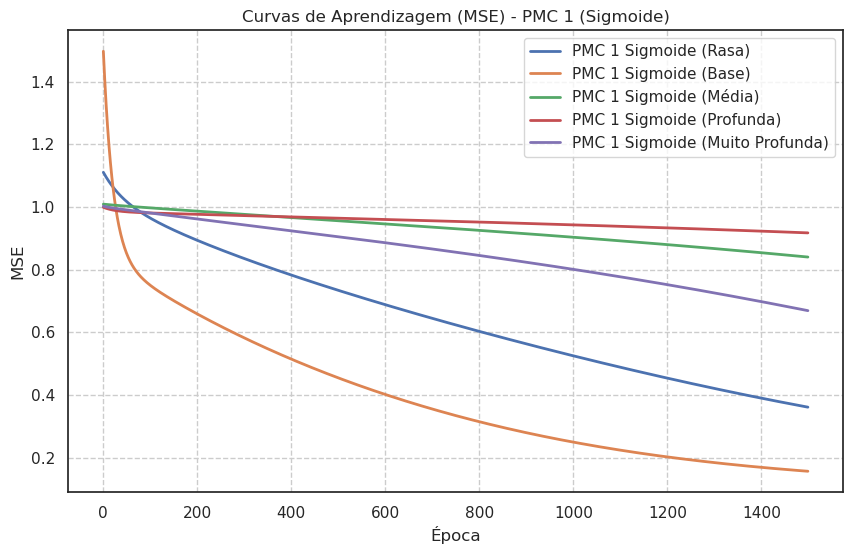

In [65]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO PERCEPTRON MULTICAMADAS (PMC)
# Algoritmo: Backpropagation (Regra Delta Generalizada - Sem Momentum)
# Parâmetros baseados no arquivo PMC1.docx e padronizados
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# 1. Preparação dos dados
df = pd.read_csv('car_price_dataset.csv')
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

features = ['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']
X = df[features].values[:1000]
y = df['Price'].values[:1000].reshape(-1, 1)

# Normalização Z-Score
medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8
X_norm = (X - medias) / desvios

media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

X_treino, X_teste = X_norm[:800], X_norm[800:1000]
y_treino, y_teste = y_norm[:800], y_norm[800:1000]
y_teste_reais = y[800:1000]

class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.0):
        self.topologia = topologia
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = []
        self.v_vieses = []

        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _derivada_sigmoid(self, a):
        return a * (1.0 - a)

    def forward(self, X):
        ativacoes = [X]
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._sigmoid(z)
            ativacoes.append(a)
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)

        grad_pesos = []
        grad_vieses = []

        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)

        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_sigmoid(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)

        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]

    def treinar(self, X, y, epocas):
        historico_mse = []
        for _ in range(epocas):
            ativacoes = self.forward(X)
            self.backward(ativacoes, y)
            mse = np.mean((ativacoes[-1] - y) ** 2)
            historico_mse.append(mse)
        return historico_mse

configuracoes = [
    {"nome": "PMC 1 Sigmoide (Rasa)", "topologia": [6, 5, 1], "camadas": "1 camada", "neuronios": "5 neurônios"},
    {"nome": "PMC 1 Sigmoide (Base)", "topologia": [6, 15, 1], "camadas": "1 camada", "neuronios": "15 neurônios"},
    {"nome": "PMC 1 Sigmoide (Média)", "topologia": [6, 16, 8, 1], "camadas": "2 camadas", "neuronios": "16 e 8 neurônios"},
    {"nome": "PMC 1 Sigmoide (Profunda)", "topologia": [6, 32, 16, 8, 1], "camadas": "3 camadas", "neuronios": "32, 16 e 8 neurônios"},
    {"nome": "PMC 1 Sigmoide (Muito Profunda)", "topologia": [6, 64, 32, 16, 1], "camadas": "3 camadas", "neuronios": "64, 32 e 16 neurônios"}
]

epocas = 1500
taxa_aprendizado = 0.005
historicos_perda = {}
modelos_treinados = []

if 'resultados_gerais' not in globals():
    resultados_gerais = []

print("Treinando variações do PMC 1 (Sigmoide) por 1500 épocas...")
for config in configuracoes:
    print(f"Treinando: {config['nome']}")
    np.random.seed(42)
    t0 = time.time()
    modelo = RedeNeuralNumpy(config['topologia'], taxa_aprendizado=taxa_aprendizado, momentum=0.0)
    historico = modelo.treinar(X_treino, y_treino, epocas)
    tempo_treino = time.time() - t0
    
    historicos_perda[config['nome']] = historico
    
    pred = modelo.forward(X_teste)[-1]
    pred_reais = pred * desvio_y + media_y
    erros_reais = y_teste_reais - pred_reais
    
    eqm_teste_real = np.mean(erros_reais**2)
    mape = np.mean(np.abs(erros_reais / y_teste_reais))
    acuracia = np.mean(np.abs(erros_reais / y_teste_reais) <= 0.10) * 100
    precisao = max(0.0, (1.0 - mape) * 100)
    
    resultados_gerais.append({
        'Modelo': config['nome'],
        'Épocas': epocas,
        'Camadas Ocultas': config['camadas'],
        'Neurônios (Ocultos)': config['neuronios'],
        'Acurácia (%)': float(acuracia),
        'Precisão (%)': float(precisao),
        'EQM (Real)': float(eqm_teste_real),
        'Tempo de Treino (s)': float(tempo_treino)
    })
    modelos_treinados.append((config['nome'], modelo))

plt.figure(figsize=(10, 6))
for nome, hist in historicos_perda.items():
    plt.plot(hist, label=nome, linewidth=2)
plt.title('Curvas de Aprendizagem (MSE) - PMC 1 (Sigmoide)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()



Treinando variações do PMC 2 (Momentum) por 1500 épocas...
Treinando: PMC 2 Momentum (Rasa)
Treinando: PMC 2 Momentum (Base)
Treinando: PMC 2 Momentum (Média)
Treinando: PMC 2 Momentum (Profunda)
Treinando: PMC 2 Momentum (Muito Profunda)


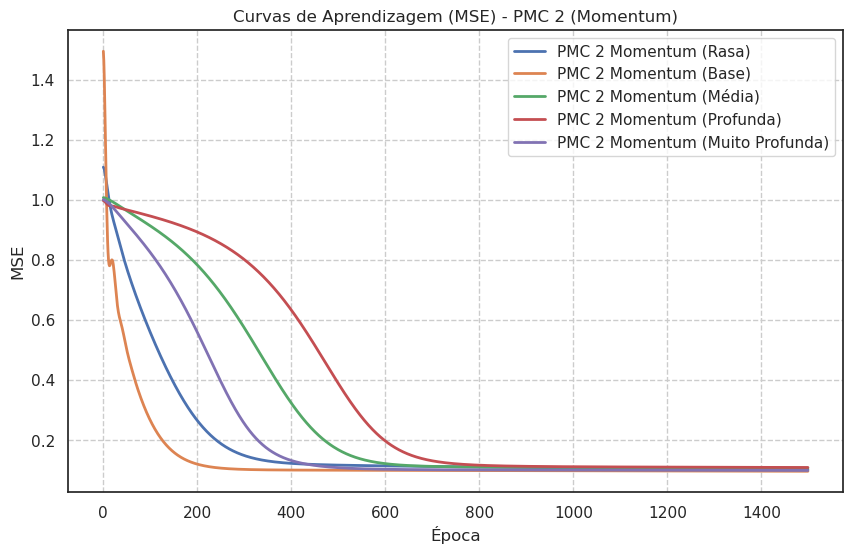

In [66]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO PERCEPTRON MULTICAMADAS (PMC) COM MOMENTUM
# Algoritmo: Backpropagation com Momentum
# Parâmetros baseados no arquivo PMC2.docx e padronizados
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# 1. Preparação dos dados
df = pd.read_csv('car_price_dataset.csv')
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

features = ['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']
X = df[features].values[:1000]
y = df['Price'].values[:1000].reshape(-1, 1)

# Normalização Z-Score
medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8
X_norm = (X - medias) / desvios

media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

X_treino, X_teste = X_norm[:800], X_norm[800:1000]
y_treino, y_teste = y_norm[:800], y_norm[800:1000]
y_teste_reais = y[800:1000]

class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.9):
        self.topologia = topologia
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = []
        self.v_vieses = []

        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _derivada_sigmoid(self, a):
        return a * (1.0 - a)

    def forward(self, X):
        ativacoes = [X]
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._sigmoid(z)
            ativacoes.append(a)
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)

        grad_pesos = []
        grad_vieses = []

        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)

        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_sigmoid(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)

        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]

    def treinar(self, X, y, epocas):
        historico_mse = []
        for _ in range(epocas):
            ativacoes = self.forward(X)
            self.backward(ativacoes, y)
            mse = np.mean((ativacoes[-1] - y) ** 2)
            historico_mse.append(mse)
        return historico_mse

configuracoes = [
    {"nome": "PMC 2 Momentum (Rasa)", "topologia": [6, 5, 1], "camadas": "1 camada", "neuronios": "5 neurônios"},
    {"nome": "PMC 2 Momentum (Base)", "topologia": [6, 15, 1], "camadas": "1 camada", "neuronios": "15 neurônios"},
    {"nome": "PMC 2 Momentum (Média)", "topologia": [6, 16, 8, 1], "camadas": "2 camadas", "neuronios": "16 e 8 neurônios"},
    {"nome": "PMC 2 Momentum (Profunda)", "topologia": [6, 32, 16, 8, 1], "camadas": "3 camadas", "neuronios": "32, 16 e 8 neurônios"},
    {"nome": "PMC 2 Momentum (Muito Profunda)", "topologia": [6, 64, 32, 16, 1], "camadas": "3 camadas", "neuronios": "64, 32 e 16 neurônios"}
]

epocas = 1500
taxa_aprendizado = 0.005
historicos_perda = {}
modelos_treinados = []

if 'resultados_gerais' not in globals():
    resultados_gerais = []

print("Treinando variações do PMC 2 (Momentum) por 1500 épocas...")
for config in configuracoes:
    print(f"Treinando: {config['nome']}")
    np.random.seed(42)
    t0 = time.time()
    modelo = RedeNeuralNumpy(config['topologia'], taxa_aprendizado=taxa_aprendizado, momentum=0.9)
    historico = modelo.treinar(X_treino, y_treino, epocas)
    tempo_treino = time.time() - t0
    
    historicos_perda[config['nome']] = historico
    
    pred = modelo.forward(X_teste)[-1]
    pred_reais = pred * desvio_y + media_y
    erros_reais = y_teste_reais - pred_reais
    
    eqm_teste_real = np.mean(erros_reais**2)
    mape = np.mean(np.abs(erros_reais / y_teste_reais))
    acuracia = np.mean(np.abs(erros_reais / y_teste_reais) <= 0.10) * 100
    precisao = max(0.0, (1.0 - mape) * 100)
    
    resultados_gerais.append({
        'Modelo': config['nome'],
        'Épocas': epocas,
        'Camadas Ocultas': config['camadas'],
        'Neurônios (Ocultos)': config['neuronios'],
        'Acurácia (%)': float(acuracia),
        'Precisão (%)': float(precisao),
        'EQM (Real)': float(eqm_teste_real),
        'Tempo de Treino (s)': float(tempo_treino)
    })
    modelos_treinados.append((config['nome'], modelo))

plt.figure(figsize=(10, 6))
for nome, hist in historicos_perda.items():
    plt.plot(hist, label=nome, linewidth=2)
plt.title('Curvas de Aprendizagem (MSE) - PMC 2 (Momentum)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()



Treinando variações do TDNN por 1500 épocas...
Treinando: TDNN (Rasa)
Treinando: TDNN (Base)
Treinando: TDNN (Média)
Treinando: TDNN (Profunda)
Treinando: TDNN (Muito Profunda)


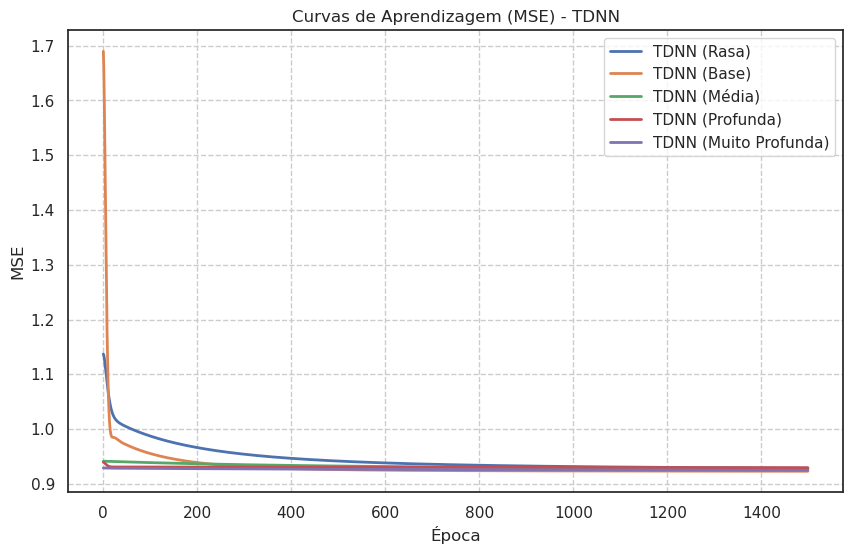

--- Previsões nos 10 primeiros carros de teste (TDNN) ---


,Linha CSV,Preço Real,TDNN (Rasa),TDNN (Base),TDNN (Média),TDNN (Profunda),TDNN (Muito Profunda)
0,800,"R$ 6,012.00","R$ 8,947.55","R$ 8,866.65","R$ 8,802.71","R$ 8,829.12","R$ 8,799.73"
1,801,"R$ 4,008.00","R$ 8,473.20","R$ 8,501.56","R$ 8,657.39","R$ 8,849.61","R$ 8,535.48"
2,802,"R$ 9,379.00","R$ 8,822.71","R$ 8,779.89","R$ 8,674.59","R$ 8,839.72","R$ 8,759.28"
3,803,"R$ 9,617.00","R$ 8,931.92","R$ 8,827.48","R$ 8,699.82","R$ 8,741.05","R$ 8,823.11"
4,804,"R$ 6,843.00","R$ 8,604.83","R$ 8,803.07","R$ 8,932.14","R$ 8,830.10","R$ 8,820.30"
5,805,"R$ 7,438.00","R$ 8,589.07","R$ 8,455.13","R$ 8,895.81","R$ 8,812.87","R$ 8,664.99"
6,806,"R$ 13,901.00","R$ 8,532.09","R$ 8,495.68","R$ 8,767.30","R$ 8,838.23","R$ 8,687.77"
7,807,"R$ 3,441.00","R$ 9,190.48","R$ 9,141.90","R$ 8,836.33","R$ 8,807.46","R$ 9,099.67"
8,808,"R$ 6,354.00","R$ 9,013.36","R$ 8,819.17","R$ 8,905.04","R$ 8,874.84","R$ 8,771.65"
9,809,"R$ 11,567.00","R$ 8,225.09","R$ 8,425.55","R$ 8,628.04","R$ 8,846.18","R$ 8,540.73"


In [67]:
# ==================================================================
# TDNN (TIME DELAY) - TREINAMENTO E TESTE DAS 5 CONFIGURAÇÕES
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

serie_preco = df_limpo['Price'].values
preco_min, preco_max = serie_preco.min(), serie_preco.max()

# Normalização Z-Score para a Série do TDNN
media_p = np.mean(serie_preco)
desvio_p = np.std(serie_preco)
serie_norm = (serie_preco - media_p) / desvio_p

def criar_janelas(serie, p):
    X, Y = [], []
    for i in range(len(serie) - p):
        X.append(serie[i : i + p])
        Y.append(serie[i + p])
    return np.array(X), np.array(Y).reshape(-1, 1)

p = 6  # Janela de atraso fixada em 6 para bater com a topologia [6, ...]
X_tdnn, y_tdnn = criar_janelas(serie_norm, p)

X_treino, y_treino = X_tdnn[:800 - p], y_tdnn[:800 - p]
X_teste, y_teste = X_tdnn[800 - p:1000 - p], y_tdnn[800 - p:1000 - p]
y_teste_reais = y_tdnn[800 - p:1000 - p] * desvio_p + media_p

class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.8):
        self.topologia = topologia
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = []
        self.v_vieses = []

        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _derivada_sigmoid(self, a):
        return a * (1.0 - a)

    def forward(self, X):
        ativacoes = [X]
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._sigmoid(z)
            ativacoes.append(a)
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)

        grad_pesos = []
        grad_vieses = []

        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)

        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_sigmoid(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)

        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]

    def treinar(self, X, y, epocas):
        historico_mse = []
        for _ in range(epocas):
            ativacoes = self.forward(X)
            self.backward(ativacoes, y)
            mse = np.mean((ativacoes[-1] - y) ** 2)
            historico_mse.append(mse)
        return historico_mse

configuracoes = [
    {"nome": "TDNN (Rasa)", "topologia": [6, 5, 1], "camadas": "1 camada", "neuronios": "5 neurônios"},
    {"nome": "TDNN (Base)", "topologia": [6, 15, 1], "camadas": "1 camada", "neuronios": "15 neurônios"},
    {"nome": "TDNN (Média)", "topologia": [6, 16, 8, 1], "camadas": "2 camadas", "neuronios": "16 e 8 neurônios"},
    {"nome": "TDNN (Profunda)", "topologia": [6, 32, 16, 8, 1], "camadas": "3 camadas", "neuronios": "32, 16 e 8 neurônios"},
    {"nome": "TDNN (Muito Profunda)", "topologia": [6, 64, 32, 16, 1], "camadas": "3 camadas", "neuronios": "64, 32 e 16 neurônios"}
]

epocas = 1500
taxa_aprendizado = 0.005
historicos_perda = {}
modelos_treinados = []

if 'resultados_gerais' not in globals():
    resultados_gerais = []

print("Treinando variações do TDNN por 1500 épocas...")
for config in configuracoes:
    print(f"Treinando: {config['nome']}")
    np.random.seed(42)
    t0 = time.time()
    modelo = RedeNeuralNumpy(config['topologia'], taxa_aprendizado=taxa_aprendizado, momentum=0.8)
    historico = modelo.treinar(X_treino, y_treino, epocas)
    tempo_treino = time.time() - t0
    
    historicos_perda[config['nome']] = historico
    
    pred = modelo.forward(X_teste)[-1]
    pred_reais = pred * desvio_p + media_p
    erros_reais = y_teste_reais - pred_reais
    
    eqm_teste_real = np.mean(erros_reais**2)
    mape = np.mean(np.abs(erros_reais / y_teste_reais))
    acuracia = np.mean(np.abs(erros_reais / y_teste_reais) <= 0.10) * 100
    precisao = max(0.0, (1.0 - mape) * 100)
    
    resultados_gerais.append({
        'Modelo': config['nome'],
        'Épocas': epocas,
        'Camadas Ocultas': config['camadas'],
        'Neurônios (Ocultos)': config['neuronios'],
        'Acurácia (%)': float(acuracia),
        'Precisão (%)': float(precisao),
        'EQM (Real)': float(eqm_teste_real),
        'Tempo de Treino (s)': float(tempo_treino)
    })
    modelos_treinados.append((config['nome'], modelo))

plt.figure(figsize=(10, 6))
for nome, hist in historicos_perda.items():
    plt.plot(hist, label=nome, linewidth=2)
plt.title('Curvas de Aprendizagem (MSE) - TDNN')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

# Teste Prático com 10 Carros
resultados_10 = []
for i in range(10):
    linha_original = 800 + i
    preco_real = float(y_teste_reais[i][0])
    row_dict = {"Linha CSV": linha_original, "Preço Real": preco_real}
    for nome, modelo in modelos_treinados:
        carro_x = X_teste[i].reshape(1, -1)
        prev = float(modelo.forward(carro_x)[-1][0][0] * desvio_p + media_p)
        row_dict[nome] = prev
    resultados_10.append(row_dict)

df_res_10 = pd.DataFrame(resultados_10)
for col in df_res_10.columns:
    if col != "Linha CSV":
        df_res_10[col] = df_res_10[col].apply("R$ {:,.2f}".format)

print("--- Previsões nos 10 primeiros carros de teste (TDNN) ---")
display(df_res_10)



Treinando variações do MLP Sigmoide por 1500 épocas...
Treinando: MLP Sigmoide (Rasa)


Treinando: MLP Sigmoide (Base)
Treinando: MLP Sigmoide (Média)
Treinando: MLP Sigmoide (Profunda)
Treinando: MLP Sigmoide (Muito Profunda)


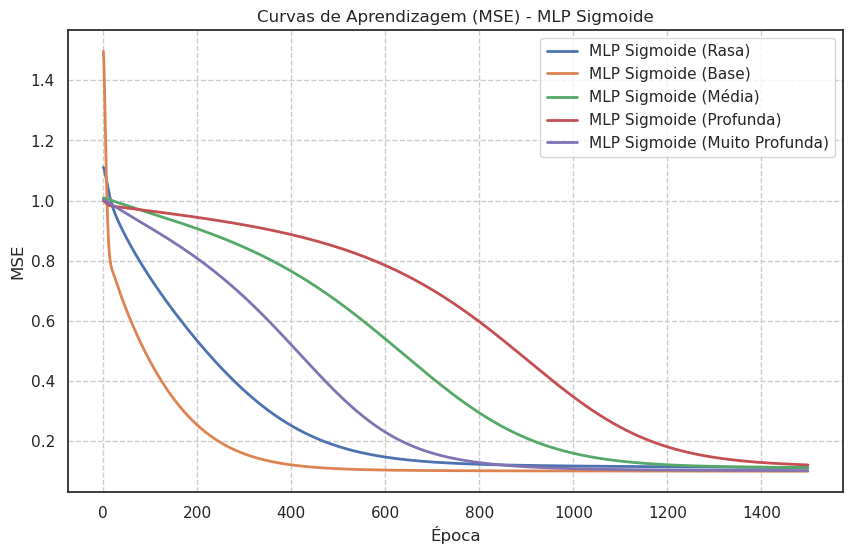

In [68]:
# ---------------------------------------------------------
# BLOCO 1: Pré-processamento Manual (Sem sklearn)
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

df = pd.read_csv('car_price_dataset.csv')

# Mapeamento do Tipo_Combustivel
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

# Separar X e y
X = df[['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']].values[:1000]
y = df['Price'].values[:1000].reshape(-1, 1)

# Normalização Z-Score
medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8
X_norm = (X - medias) / desvios

# Normalizar Y
media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

# Divisão de Treino (800) e Teste (200)
X_treino, X_teste = X_norm[:800], X_norm[800:1000]
y_treino, y_teste = y_norm[:800], y_norm[800:1000]
y_teste_reais = y[800:1000]
idx_teste = np.arange(800, 1000)

# ---------------------------------------------------------
# BLOCO 2: A Classe da Rede Neural
# ---------------------------------------------------------
class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.8):
        self.topologia = topologia
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = []
        self.v_vieses = []
        
        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))
    
    def _derivada_sigmoid(self, a):
        return a * (1.0 - a)

    def forward(self, X):
        ativacoes = [X]
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._sigmoid(z)
            ativacoes.append(a)
            
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)
        
        grad_pesos = []
        grad_vieses = []
        
        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)
        
        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_sigmoid(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)
            
        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]
            
    def treinar(self, X, y, epocas):
        historico_mse = []
        for _ in range(epocas):
            ativacoes = self.forward(X)
            self.backward(ativacoes, y)
            mse = np.mean((ativacoes[-1] - y) ** 2)
            historico_mse.append(mse)
        return historico_mse

# ---------------------------------------------------------
# BLOCO 3: O Experimento de Topologias
# ---------------------------------------------------------
configuracoes = [
    {"nome": "MLP Sigmoide (Rasa)", "topologia": [6, 5, 1], "camadas": "1 camada", "neuronios": "5 neurônios"},
    {"nome": "MLP Sigmoide (Base)", "topologia": [6, 15, 1], "camadas": "1 camada", "neuronios": "15 neurônios"},
    {"nome": "MLP Sigmoide (Média)", "topologia": [6, 16, 8, 1], "camadas": "2 camadas", "neuronios": "16 e 8 neurônios"},
    {"nome": "MLP Sigmoide (Profunda)", "topologia": [6, 32, 16, 8, 1], "camadas": "3 camadas", "neuronios": "32, 16 e 8 neurônios"},
    {"nome": "MLP Sigmoide (Muito Profunda)", "topologia": [6, 64, 32, 16, 1], "camadas": "3 camadas", "neuronios": "64, 32 e 16 neurônios"}
]

epocas = 1500
taxa_aprendizado = 0.005
historicos_perda = {}
modelos_treinados = []

if 'resultados_gerais' not in globals():
    resultados_gerais = []

print("Treinando variações do MLP Sigmoide por 1500 épocas...")
for config in configuracoes:
    print(f"Treinando: {config['nome']}")
    np.random.seed(42)
    t0 = time.time()
    modelo = RedeNeuralNumpy(config['topologia'], taxa_aprendizado=taxa_aprendizado, momentum=0.8)
    historico = modelo.treinar(X_treino, y_treino, epocas)
    tempo_treino = time.time() - t0
    
    historicos_perda[config['nome']] = historico
    
    pred = modelo.forward(X_teste)[-1]
    pred_reais = pred * desvio_y + media_y
    erros_reais = y_teste_reais - pred_reais
    
    eqm_teste_real = np.mean(erros_reais**2)
    mape = np.mean(np.abs(erros_reais / y_teste_reais))
    acuracia = np.mean(np.abs(erros_reais / y_teste_reais) <= 0.10) * 100
    precisao = max(0.0, (1.0 - mape) * 100)
    
    resultados_gerais.append({
        'Modelo': config['nome'],
        'Épocas': epocas,
        'Camadas Ocultas': config['camadas'],
        'Neurônios (Ocultos)': config['neuronios'],
        'Acurácia (%)': float(acuracia),
        'Precisão (%)': float(precisao),
        'EQM (Real)': float(eqm_teste_real),
        'Tempo de Treino (s)': float(tempo_treino)
    })
    modelos_treinados.append((config['nome'], modelo))

# Plotagem da Curva de Aprendizado Combinada
plt.figure(figsize=(10, 6))
for nome, hist in historicos_perda.items():
    plt.plot(hist, label=nome, linewidth=2)
plt.title('Curvas de Aprendizagem (MSE) - MLP Sigmoide')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()



In [69]:
# ---------------------------------------------------------
# BLOCO 5: Teste Prático com 10 Carros (Tabela Comparativa)
# ---------------------------------------------------------
import pandas as pd
from IPython.display import display

resultados_10 = []
for i in range(10):
    linha_original = 800 + i
    preco_real = float(y_teste_reais[i][0])
    row_dict = {"Linha CSV": linha_original, "Preço Real": preco_real}
    for nome, modelo in modelos_treinados:
        carro_x = X_teste[i].reshape(1, -1)
        prev = float(modelo.forward(carro_x)[-1][0][0] * desvio_y + media_y)
        row_dict[nome] = prev
    resultados_10.append(row_dict)

df_res_10 = pd.DataFrame(resultados_10)
for col in df_res_10.columns:
    if col != "Linha CSV":
        df_res_10[col] = df_res_10[col].apply("R$ {:,.2f}".format)

print("--- Previsões nos 10 primeiros carros de teste (MLP Sigmoide) ---")
display(df_res_10)



--- Previsões nos 10 primeiros carros de teste (MLP Sigmoide) ---


,Linha CSV,Preço Real,MLP Sigmoide (Rasa),MLP Sigmoide (Base),MLP Sigmoide (Média),MLP Sigmoide (Profunda),MLP Sigmoide (Muito Profunda)
0,800,"R$ 6,012.00","R$ 5,493.24","R$ 5,260.23","R$ 5,211.53","R$ 5,423.41","R$ 5,379.70"
1,801,"R$ 4,008.00","R$ 5,393.09","R$ 5,301.82","R$ 5,500.82","R$ 5,579.34","R$ 5,251.22"
2,802,"R$ 9,379.00","R$ 10,599.19","R$ 10,615.87","R$ 10,510.53","R$ 10,642.41","R$ 10,771.96"
3,803,"R$ 9,617.00","R$ 10,416.72","R$ 10,337.93","R$ 10,270.59","R$ 10,103.54","R$ 10,517.05"
4,804,"R$ 6,843.00","R$ 7,583.19","R$ 7,721.97","R$ 7,674.04","R$ 7,721.60","R$ 7,479.58"
5,805,"R$ 7,438.00","R$ 7,685.68","R$ 7,788.60","R$ 7,631.16","R$ 7,494.94","R$ 7,521.23"
6,806,"R$ 13,901.00","R$ 13,108.52","R$ 13,203.93","R$ 13,450.28","R$ 13,179.94","R$ 13,556.35"
7,807,"R$ 3,441.00","R$ 5,198.10","R$ 4,548.04","R$ 4,366.08","R$ 4,828.16","R$ 4,630.41"
8,808,"R$ 6,354.00","R$ 4,926.61","R$ 4,504.83","R$ 4,970.69","R$ 4,880.76","R$ 4,527.25"
9,809,"R$ 11,567.00","R$ 11,143.01","R$ 11,116.43","R$ 11,280.94","R$ 11,187.71","R$ 10,900.31"


Treinando variações do MLP ReLU por 1500 épocas...
Treinando: MLP ReLU (Rasa)
Treinando: MLP ReLU (Base)
Treinando: MLP ReLU (Média)
Treinando: MLP ReLU (Profunda)
Treinando: MLP ReLU (Muito Profunda)


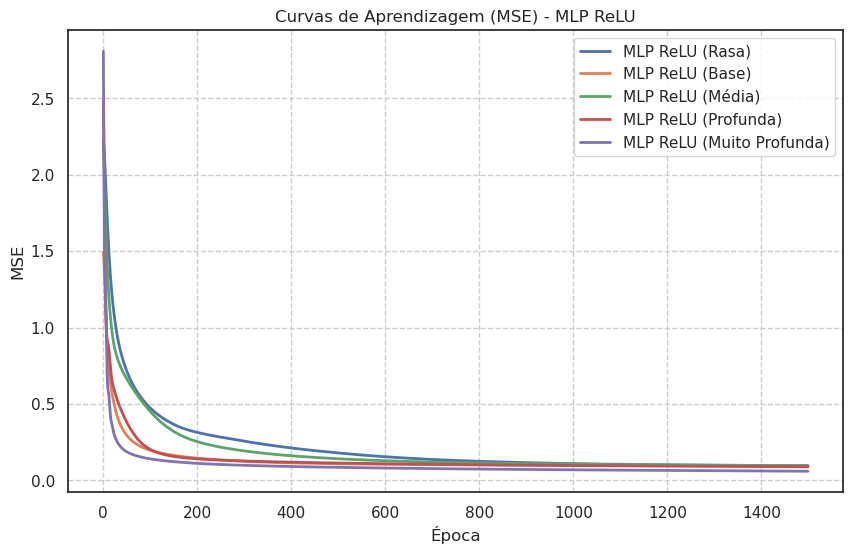

--- Previsões nos 10 primeiros carros de teste (MLP ReLU) ---


,Linha CSV,Preço Real,MLP ReLU (Rasa),MLP ReLU (Base),MLP ReLU (Média),MLP ReLU (Profunda),MLP ReLU (Muito Profunda)
0,800,"R$ 6,012.00","R$ 6,085.78","R$ 6,157.53","R$ 5,672.16","R$ 5,762.37","R$ 6,694.42"
1,801,"R$ 4,008.00","R$ 5,201.85","R$ 4,642.60","R$ 4,828.30","R$ 5,245.95","R$ 4,253.73"
2,802,"R$ 9,379.00","R$ 10,076.77","R$ 10,547.65","R$ 10,182.61","R$ 10,511.27","R$ 9,798.53"
3,803,"R$ 9,617.00","R$ 10,038.54","R$ 10,130.71","R$ 9,817.83","R$ 9,843.19","R$ 10,463.79"
4,804,"R$ 6,843.00","R$ 7,969.93","R$ 8,363.64","R$ 7,906.98","R$ 8,210.41","R$ 8,039.11"
5,805,"R$ 7,438.00","R$ 7,664.15","R$ 7,830.28","R$ 8,231.41","R$ 8,131.35","R$ 7,728.80"
6,806,"R$ 13,901.00","R$ 13,696.50","R$ 13,997.39","R$ 13,522.66","R$ 13,911.51","R$ 12,494.69"
7,807,"R$ 3,441.00","R$ 5,024.77","R$ 4,548.44","R$ 4,304.60","R$ 4,539.52","R$ 4,231.52"
8,808,"R$ 6,354.00","R$ 5,024.77","R$ 4,650.69","R$ 3,905.74","R$ 4,474.49","R$ 4,897.57"
9,809,"R$ 11,567.00","R$ 10,738.39","R$ 10,813.10","R$ 11,247.81","R$ 10,429.27","R$ 10,712.60"


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import display

# ---------------------------------------------------------
# BLOCO 1: Pré-processamento Manual (Sem sklearn)
# ---------------------------------------------------------
df = pd.read_csv('car_price_dataset.csv')
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

X = df[['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']].values[:1000]
y = df['Price'].values[:1000].reshape(-1, 1)

medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8
X_norm = (X - medias) / desvios

media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

X_treino, X_teste = X_norm[:800], X_norm[800:1000]
y_treino, y_teste = y_norm[:800], y_norm[800:1000]
y_teste_reais = y[800:1000]
idx_teste = np.arange(800, 1000)

# ---------------------------------------------------------
# BLOCO 2: A Classe da Rede Neural (ReLU)
# ---------------------------------------------------------
class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.8):
        self.topologia = topologia
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = []
        self.v_vieses = []
        
        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _relu(self, z):
        return np.maximum(0, z)
    
    def _derivada_relu(self, a):
        return (a > 0).astype(float)

    def forward(self, X):
        ativacoes = [X]
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._relu(z)
            ativacoes.append(a)
            
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)
        
        grad_pesos = []
        grad_vieses = []
        
        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)
        
        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_relu(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)
            
        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]
            
    def treinar(self, X, y, epocas):
        historico_mse = []
        for _ in range(epocas):
            ativacoes = self.forward(X)
            self.backward(ativacoes, y)
            mse = np.mean((ativacoes[-1] - y) ** 2)
            historico_mse.append(mse)
        return historico_mse

# ---------------------------------------------------------
# BLOCO 3: O Experimento de Topologias
# ---------------------------------------------------------
configuracoes = [
    {"nome": "MLP ReLU (Rasa)", "topologia": [6, 5, 1], "camadas": "1 camada", "neuronios": "5 neurônios"},
    {"nome": "MLP ReLU (Base)", "topologia": [6, 15, 1], "camadas": "1 camada", "neuronios": "15 neurônios"},
    {"nome": "MLP ReLU (Média)", "topologia": [6, 16, 8, 1], "camadas": "2 camadas", "neuronios": "16 e 8 neurônios"},
    {"nome": "MLP ReLU (Profunda)", "topologia": [6, 32, 16, 8, 1], "camadas": "3 camadas", "neuronios": "32, 16 e 8 neurônios"},
    {"nome": "MLP ReLU (Muito Profunda)", "topologia": [6, 64, 32, 16, 1], "camadas": "3 camadas", "neuronios": "64, 32 e 16 neurônios"}
]

epocas = 1500
taxa_aprendizado = 0.005
historicos_perda = {}
modelos_treinados = []

if 'resultados_gerais' not in globals():
    resultados_gerais = []

print("Treinando variações do MLP ReLU por 1500 épocas...")
for config in configuracoes:
    print(f"Treinando: {config['nome']}")
    np.random.seed(42)
    t0 = time.time()
    modelo = RedeNeuralNumpy(config['topologia'], taxa_aprendizado=taxa_aprendizado, momentum=0.8)
    historico = modelo.treinar(X_treino, y_treino, epocas)
    tempo_treino = time.time() - t0
    
    historicos_perda[config['nome']] = historico
    
    pred = modelo.forward(X_teste)[-1]
    pred_reais = pred * desvio_y + media_y
    erros_reais = y_teste_reais - pred_reais
    
    eqm_teste_real = np.mean(erros_reais**2)
    mape = np.mean(np.abs(erros_reais / y_teste_reais))
    acuracia = np.mean(np.abs(erros_reais / y_teste_reais) <= 0.10) * 100
    precisao = max(0.0, (1.0 - mape) * 100)
    
    resultados_gerais.append({
        'Modelo': config['nome'],
        'Épocas': epocas,
        'Camadas Ocultas': config['camadas'],
        'Neurônios (Ocultos)': config['neuronios'],
        'Acurácia (%)': float(acuracia),
        'Precisão (%)': float(precisao),
        'EQM (Real)': float(eqm_teste_real),
        'Tempo de Treino (s)': float(tempo_treino)
    })
    modelos_treinados.append((config['nome'], modelo))

# Plotagem da Curva de Aprendizado Combinada
plt.figure(figsize=(10, 6))
for nome, hist in historicos_perda.items():
    plt.plot(hist, label=nome, linewidth=2)
plt.title('Curvas de Aprendizagem (MSE) - MLP ReLU')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

# Teste Prático com 10 Carros
resultados_10 = []
for i in range(10):
    linha_original = 800 + i
    preco_real = float(y_teste_reais[i][0])
    row_dict = {"Linha CSV": linha_original, "Preço Real": preco_real}
    for nome, modelo in modelos_treinados:
        carro_x = X_teste[i].reshape(1, -1)
        prev = float(modelo.forward(carro_x)[-1][0][0] * desvio_y + media_y)
        row_dict[nome] = prev
    resultados_10.append(row_dict)

df_res_10 = pd.DataFrame(resultados_10)
for col in df_res_10.columns:
    if col != "Linha CSV":
        df_res_10[col] = df_res_10[col].apply("R$ {:,.2f}".format)

print("--- Previsões nos 10 primeiros carros de teste (MLP ReLU) ---")
display(df_res_10)



Treinando variações do MLP Lotes por 1500 épocas...
Treinando: MLP Lotes (Rasa)
Treinando: MLP Lotes (Base)
Treinando: MLP Lotes (Média)
Treinando: MLP Lotes (Profunda)
Treinando: MLP Lotes (Muito Profunda)


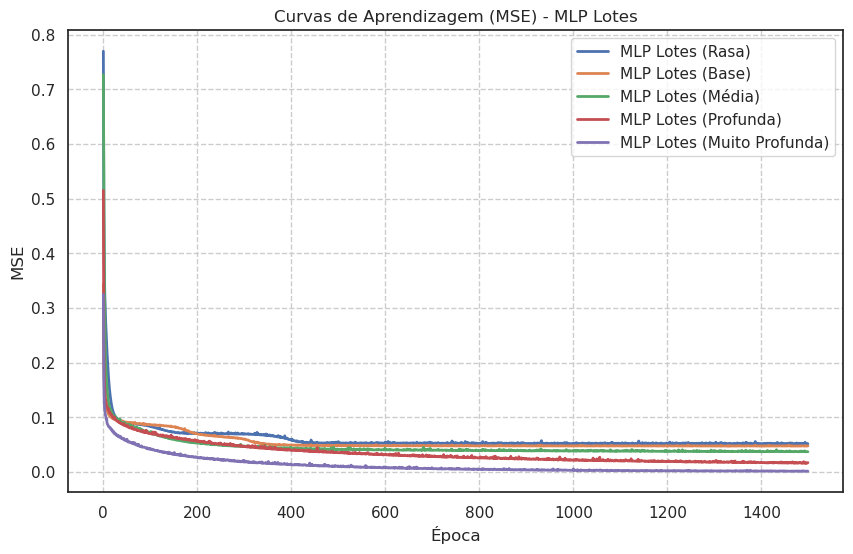

--- Previsões nos 10 primeiros carros de teste (MLP Lotes) ---


,Linha CSV,Preço Real,MLP Lotes (Rasa),MLP Lotes (Base),MLP Lotes (Média),MLP Lotes (Profunda),MLP Lotes (Muito Profunda)
0,800,"R$ 6,012.00","R$ 5,082.11","R$ 5,164.43","R$ 4,900.28","R$ 6,268.59","R$ 6,588.22"
1,801,"R$ 4,008.00","R$ 4,235.95","R$ 4,086.29","R$ 3,870.19","R$ 5,889.75","R$ 4,754.31"
2,802,"R$ 9,379.00","R$ 9,745.81","R$ 10,003.81","R$ 9,904.88","R$ 11,634.98","R$ 10,041.98"
3,803,"R$ 9,617.00","R$ 10,289.62","R$ 10,116.86","R$ 10,392.70","R$ 9,962.16","R$ 9,553.60"
4,804,"R$ 6,843.00","R$ 7,447.18","R$ 7,202.06","R$ 6,723.61","R$ 6,779.81","R$ 7,388.72"
5,805,"R$ 7,438.00","R$ 8,115.00","R$ 8,070.72","R$ 7,903.18","R$ 7,695.57","R$ 7,782.32"
6,806,"R$ 13,901.00","R$ 14,335.22","R$ 13,979.25","R$ 14,484.22","R$ 14,751.66","R$ 13,632.14"
7,807,"R$ 3,441.00","R$ 3,825.79","R$ 4,060.70","R$ 3,916.35","R$ 3,427.35","R$ 3,534.07"
8,808,"R$ 6,354.00","R$ 5,089.65","R$ 5,286.41","R$ 4,424.91","R$ 5,416.64","R$ 4,696.55"
9,809,"R$ 11,567.00","R$ 10,362.39","R$ 10,552.17","R$ 11,083.17","R$ 10,850.07","R$ 11,654.04"


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import display

# =========================================================
# BLOCO 1: Pré-processamento Manual (Sem sklearn)
# =========================================================
df = pd.read_csv('car_price_dataset.csv')
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

X = df[['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']].values[:1000]
y = df['Price'].values[:1000].reshape(-1, 1)

medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8
X_norm = (X - medias) / desvios

media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

X_treino, X_teste = X_norm[:800], X_norm[800:1000]
y_treino, y_teste = y_norm[:800], y_norm[800:1000]
y_teste_reais = y[800:1000]
idx_teste = np.arange(800, 1000)

# =========================================================
# BLOCO 2: A Classe da Rede Neural (Lotes e Decaimento)
# =========================================================
class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.9):
        self.topologia = topologia
        self.lr_inicial = taxa_aprendizado
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = []
        self.v_vieses = []
        
        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _relu(self, z):
        return np.maximum(0, z)
    
    def _derivada_relu(self, a):
        return (a > 0).astype(float)

    def forward(self, X):
        ativacoes = [X]
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._relu(z)
            ativacoes.append(a)
            
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)
        
        grad_pesos = []
        grad_vieses = []
        
        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)
        
        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_relu(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)
            
        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]
            
    def treinar(self, X, y, epocas, tamanho_lote=32):
        historico_mse = []
        m_total = X.shape[0]
        
        for epoca in range(epocas):
            self.lr = self.lr_inicial * (0.95 ** (epoca / 500))
            indices = np.random.permutation(m_total)
            X_embaralhado = X[indices]
            y_embaralhado = y[indices]
            
            for i in range(0, m_total, tamanho_lote):
                X_lote = X_embaralhado[i : i + tamanho_lote]
                y_lote = y_embaralhado[i : i + tamanho_lote]
                ativacoes = self.forward(X_lote)
                self.backward(ativacoes, y_lote)
                
            ativacoes_totais = self.forward(X)
            mse = np.mean((ativacoes_totais[-1] - y) ** 2)
            historico_mse.append(mse)
            
        return historico_mse

# =========================================================
# BLOCO 3: O Experimento de Topologias
# =========================================================
configuracoes = [
    {"nome": "MLP Lotes (Rasa)", "topologia": [6, 5, 1], "camadas": "1 camada", "neuronios": "5 neurônios"},
    {"nome": "MLP Lotes (Base)", "topologia": [6, 15, 1], "camadas": "1 camada", "neuronios": "15 neurônios"},
    {"nome": "MLP Lotes (Média)", "topologia": [6, 16, 8, 1], "camadas": "2 camadas", "neuronios": "16 e 8 neurônios"},
    {"nome": "MLP Lotes (Profunda)", "topologia": [6, 32, 16, 8, 1], "camadas": "3 camadas", "neuronios": "32, 16 e 8 neurônios"},
    {"nome": "MLP Lotes (Muito Profunda)", "topologia": [6, 64, 32, 16, 1], "camadas": "3 camadas", "neuronios": "64, 32 e 16 neurônios"}
]

epocas = 1500
taxa_aprendizado = 0.005
tamanho_do_lote = 32
historicos_perda = {}
modelos_treinados = []

if 'resultados_gerais' not in globals():
    resultados_gerais = []

print("Treinando variações do MLP Lotes por 1500 épocas...")
for config in configuracoes:
    print(f"Treinando: {config['nome']}")
    np.random.seed(42)
    t0 = time.time()
    modelo = RedeNeuralNumpy(config['topologia'], taxa_aprendizado=taxa_aprendizado, momentum=0.9)
    historico = modelo.treinar(X_treino, y_treino, epocas, tamanho_do_lote)
    tempo_treino = time.time() - t0
    
    historicos_perda[config['nome']] = historico
    
    pred = modelo.forward(X_teste)[-1]
    pred_reais = pred * desvio_y + media_y
    erros_reais = y_teste_reais - pred_reais
    
    eqm_teste_real = np.mean(erros_reais**2)
    mape = np.mean(np.abs(erros_reais / y_teste_reais))
    acuracia = np.mean(np.abs(erros_reais / y_teste_reais) <= 0.10) * 100
    precisao = max(0.0, (1.0 - mape) * 100)
    
    resultados_gerais.append({
        'Modelo': config['nome'],
        'Épocas': epocas,
        'Camadas Ocultas': config['camadas'],
        'Neurônios (Ocultos)': config['neuronios'],
        'Acurácia (%)': float(acuracia),
        'Precisão (%)': float(precisao),
        'EQM (Real)': float(eqm_teste_real),
        'Tempo de Treino (s)': float(tempo_treino)
    })
    modelos_treinados.append((config['nome'], modelo))

plt.figure(figsize=(10, 6))
for nome, hist in historicos_perda.items():
    plt.plot(hist, label=nome, linewidth=2)
plt.title('Curvas de Aprendizagem (MSE) - MLP Lotes')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

# Teste Prático com 10 Carros
resultados_10 = []
for i in range(10):
    linha_original = 800 + i
    preco_real = float(y_teste_reais[i][0])
    row_dict = {"Linha CSV": linha_original, "Preço Real": preco_real}
    for nome, modelo in modelos_treinados:
        carro_x = X_teste[i].reshape(1, -1)
        prev = float(modelo.forward(carro_x)[-1][0][0] * desvio_y + media_y)
        row_dict[nome] = prev
    resultados_10.append(row_dict)

df_res_10 = pd.DataFrame(resultados_10)
for col in df_res_10.columns:
    if col != "Linha CSV":
        df_res_10[col] = df_res_10[col].apply("R$ {:,.2f}".format)

print("--- Previsões nos 10 primeiros carros de teste (MLP Lotes) ---")
display(df_res_10)



In [ ]:
# ==================================================================
# TABELA COMPARATIVA DE DESEMPENHO (LEADERBOARD GERAL)
# ==================================================================
import pandas as pd

if 'resultados_gerais' in globals() and resultados_gerais:
    df_comparativo = pd.DataFrame(resultados_gerais)
    
    # Remover duplicatas (mantendo a última execução) e linhas com valores nulos nas colunas de arquitetura
    df_comparativo = df_comparativo.dropna(subset=['Camadas Ocultas'])
    df_comparativo = df_comparativo.drop_duplicates(subset=['Modelo'], keep='last')
    
    # Reordenar colunas para exibir arquitetura seguida pelo desempenho
    colunas_ordem = [
        'Modelo', 'Épocas', 'Camadas Ocultas', 'Neurônios (Ocultos)',
        'Acurácia (%)', 'Precisão (%)', 'EQM (Real)', 'Tempo de Treino (s)'
    ]
    colunas_ordem = [c for c in colunas_ordem if c in df_comparativo.columns]
    df_comparativo = df_comparativo[colunas_ordem]
    
    # Ordenar do melhor para o pior: Acurácia decrescente, depois Precisão decrescente
    df_comparativo = df_comparativo.sort_values(by=['Acurácia (%)', 'Precisão (%)'], ascending=[False, False])
    
    # Formatação visual
    df_formatado = df_comparativo.copy()
    df_formatado['Acurácia (%)'] = df_formatado['Acurácia (%)'].apply("{:.2f}%".format)
    df_formatado['Precisão (%)'] = df_formatado['Precisão (%)'].apply("{:.2f}%".format)
    df_formatado['EQM (Real)'] = df_formatado['EQM (Real)'].apply("$ {:,.2f}".format)
    df_formatado['Tempo de Treino (s)'] = df_formatado['Tempo de Treino (s)'].apply("{:.4f}s".format)
    
    print("="*110)
    print("                 LEADERBOARD GERAL: COMPARATIVO DE MODELOS E ARQUITETURAS")
    print("="*110)
    display(df_formatado)
else:
    print("Nenhum resultado de modelo foi registrado.")


                 LEADERBOARD GERAL: COMPARATIVO DE MODELOS E ARQUITETURAS


,Modelo,Épocas,Camadas Ocultas,Neurônios (Ocultos),Acurácia (%),Precisão (%),EQM (Real),Tempo de Treino (s)
26,MLP Lotes (Rasa),1500,1 camada,5 neurônios,73.50%,91.66%,"R$ 529,840.65",2.4557s
27,MLP Lotes (Base),1500,1 camada,15 neurônios,72.00%,91.66%,"R$ 571,876.24",2.9826s
28,MLP Lotes (Média),1500,2 camadas,16 e 8 neurônios,70.00%,91.37%,"R$ 671,099.95",4.2010s
0,Adaline,2,0 camadas,Sem neurônios ocultos,61.50%,89.39%,"R$ 947,924.71",0.0134s
21,MLP ReLU (Rasa),1500,1 camada,5 neurônios,59.50%,89.68%,"R$ 930,930.19",0.2607s
25,MLP ReLU (Muito Profunda),1500,3 camadas,"64, 32 e 16 neurônios",59.00%,89.64%,"R$ 1,073,153.41",2.7133s
24,MLP ReLU (Profunda),1500,3 camadas,"32, 16 e 8 neurônios",58.00%,89.30%,"R$ 1,175,315.14",2.0023s
23,MLP ReLU (Média),1500,2 camadas,16 e 8 neurônios,56.00%,89.50%,"R$ 1,078,231.63",0.5802s
16,MLP Sigmoide (Rasa),1500,1 camada,5 neurônios,55.50%,89.13%,"R$ 1,065,601.62",0.3097s
7,PMC 2 Momentum (Base),1500,1 camada,15 neurônios,55.00%,89.44%,"R$ 967,109.11",0.7894s
